In [1]:
# ============================================================
# F1 — Week 05 Black Box Optimisation
# Structure: Config → Load → Surrogate → Acquisition → Diagnostics → Output
# ============================================================

# -----------------------------
# Imports (top of notebook)
# -----------------------------
import os
import warnings
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error

from scipy.stats import qmc
from scipy.spatial.distance import cdist

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

RNG = np.random.default_rng(42)

In [2]:
# ============================================================
# 0) Config
# ============================================================

# Your requested config paths (relative)
INPUTS_PATH = "data/F1/initial_inputs.npy"
OUTPUTS_PATH = "data/F1/initial_outputs.npy"

# Fallback to the sandbox upload paths if the relative ones don't exist
FALLBACK_INPUTS_PATH = "/mnt/data/initial_inputs.npy"
FALLBACK_OUTPUTS_PATH = "/mnt/data/initial_outputs.npy"

# Domain bounds for F1 (given: [0,1]^2)
BOUNDS_LOW = np.array([0.0, 0.0])
BOUNDS_HIGH = np.array([1.0, 1.0])

# Candidate generation + batching
N_CANDIDATES = 8192             # Sobol candidates (increase if you want)
MIN_DIST = 0.05                 # keep new point away from existing samples

# Acquisition weights (Week 04 choice carried forward)
W_EXPLORE = 0.7
W_EXPLOIT = 0.3

# Models
RF_N_ESTIMATORS = 600
GBM_ENSEMBLE_SIZE = 12

# GP numerical stability
GP_ALPHA = 1e-8

In [3]:
# ============================================================
# 1) Load
# ============================================================

def resolve_path(preferred: str, fallback: str) -> str:
    return preferred if os.path.exists(preferred) else fallback

x_path = resolve_path(INPUTS_PATH, FALLBACK_INPUTS_PATH)
y_path = resolve_path(OUTPUTS_PATH, FALLBACK_OUTPUTS_PATH)

X = np.load(x_path)   # shape (n,2)
y = np.load(y_path)   # shape (n,)

assert X.ndim == 2 and X.shape[1] == 2, f"Expected X shape (n,2); got {X.shape}"
assert y.ndim == 1 and y.shape[0] == X.shape[0], f"Expected y shape (n,); got {y.shape}"

n = X.shape[0]
print(f"Loaded F1 data: n={n}, X in [{X.min():.3f},{X.max():.3f}], y in [{y.min():.3e},{y.max():.3e}]")
print(f"Inputs path:  {x_path}")
print(f"Outputs path: {y_path}")

# Scale inputs for GP/GBM stability (RF doesn’t need it, but fine to keep consistent)
x_scaler = StandardScaler()
X_s = x_scaler.fit_transform(X)

# Scale outputs (important because F1 outputs can be extremely small / near-flat)
y_scaler = StandardScaler()
y_s = y_scaler.fit_transform(y.reshape(-1, 1)).ravel()

Loaded F1 data: n=14, X in [0.079,0.884], y in [-1.058e-02,6.583e-10]
Inputs path:  data/F1/initial_inputs.npy
Outputs path: data/F1/initial_outputs.npy


In [4]:
# ============================================================
# 2) Surrogate (GP + RF + GBM ensemble)
# ============================================================

# ---- GP ----
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=0.25, length_scale_bounds=(1e-2, 2.0), nu=2.5) \
         + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-10, 1e-1))

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=GP_ALPHA,
    normalize_y=True,
    n_restarts_optimizer=8,
    random_state=42
)
gp.fit(X_s, y_s)

# ---- RF ----
rf = RandomForestRegressor(
    n_estimators=RF_N_ESTIMATORS,
    random_state=42,
    bootstrap=True,
    max_features=1.0,
    min_samples_leaf=1,
    n_jobs=-1
)
rf.fit(X_s, y_s)

# ---- GBM ensemble ----
gbm_ens = []
for k in range(GBM_ENSEMBLE_SIZE):
    m = GradientBoostingRegressor(
        random_state=100 + k,
        n_estimators=350,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        min_samples_leaf=2
    )
    m.fit(X_s, y_s)
    gbm_ens.append(m)

In [5]:
# ============================================================
# 3) Acquisition (Sobol + distance constraint + composite score)
# ============================================================

def zscore(a: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    a = np.asarray(a).ravel()
    return (a - a.mean()) / (a.std() + eps)

def generate_sobol_candidates(n_candidates: int) -> np.ndarray:
    # Sobol in [0,1]^2 then scale to bounds (already [0,1]^2, but keep general)
    sampler = qmc.Sobol(d=2, scramble=True, seed=42)
    # Sobol prefers powers of 2; if not, it still works but may warn — suppress above
    u = sampler.random(n_candidates)
    return qmc.scale(u, BOUNDS_LOW, BOUNDS_HIGH)

def enforce_min_distance(X_existing: np.ndarray, X_cand: np.ndarray, min_dist: float) -> np.ndarray:
    d = cdist(X_cand, X_existing, metric="euclidean")
    keep = (d.min(axis=1) >= min_dist)
    return keep

# Candidates in original scale, then scaled for models
X_cand = generate_sobol_candidates(N_CANDIDATES)
keep_mask = enforce_min_distance(X, X_cand, MIN_DIST)
X_cand = X_cand[keep_mask]

if X_cand.shape[0] == 0:
    raise RuntimeError("All candidates filtered out by MIN_DIST. Reduce MIN_DIST or increase N_CANDIDATES.")

X_cand_s = x_scaler.transform(X_cand)

# --- Predict mean + uncertainty per model on candidates ---

# GP mean/std
gp_mean, gp_std = gp.predict(X_cand_s, return_std=True)

# RF mean/std from trees
rf_tree_preds = np.vstack([t.predict(X_cand_s) for t in rf.estimators_])  # (n_trees, n_cand)
rf_mean = rf_tree_preds.mean(axis=0)
rf_std = rf_tree_preds.std(axis=0)

# GBM ensemble mean/std
gbm_preds = np.vstack([m.predict(X_cand_s) for m in gbm_ens])             # (n_models, n_cand)
gbm_mean = gbm_preds.mean(axis=0)
gbm_std = gbm_preds.std(axis=0)

# Standardize means and uncertainties across candidates (so they are comparable)
mu_ens_z = (zscore(gp_mean) + zscore(rf_mean) + zscore(gbm_mean)) / 3.0
sig_ens_z = (zscore(gp_std) + zscore(rf_std) + zscore(gbm_std)) / 3.0

# Composite score: exploration + exploitation
score = W_EXPLORE * sig_ens_z + W_EXPLOIT * mu_ens_z

best_idx = int(np.argmax(score))
x_next = X_cand[best_idx]



--- Diagnostics (training, standardized y-space) ---
R²:  0.978
RMSE:0.149
Residual mean: 2.365e-02, std: 0.147


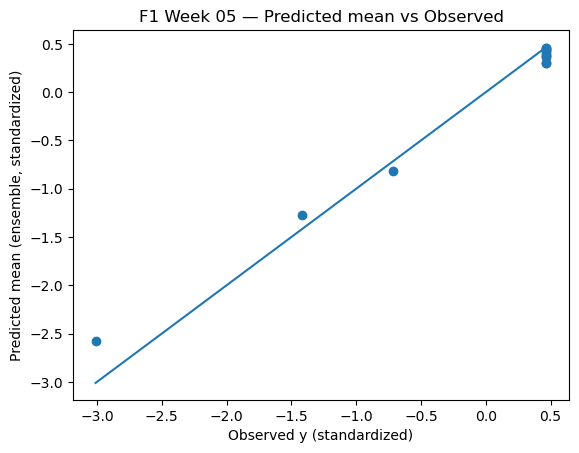

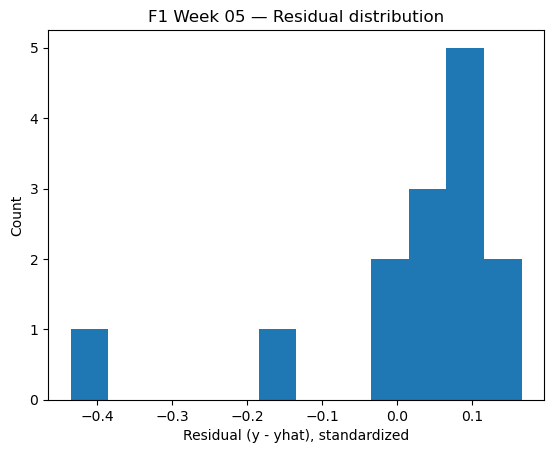

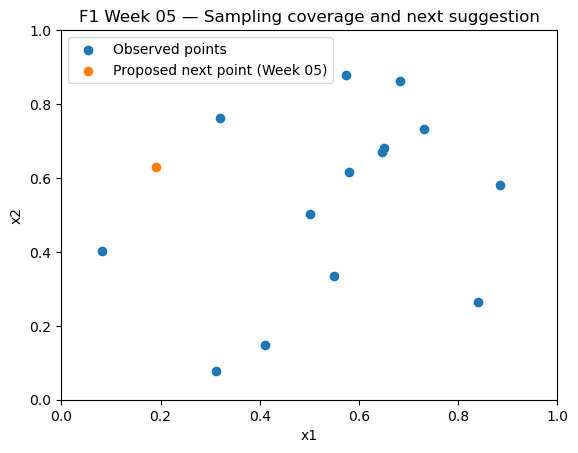

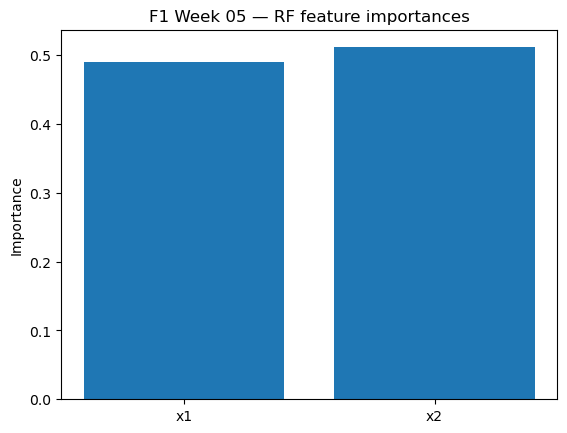


Nearest-neighbour distance of x_next to existing samples: 0.1851 (MIN_DIST=0.05)


In [7]:
# ============================================================
# 4) Diagnostics
# ============================================================

# Evaluate training fit (in standardized y-space)
gp_train_mean, gp_train_std = gp.predict(X_s, return_std=True)

rf_train_tree_preds = np.vstack([t.predict(X_s) for t in rf.estimators_])
rf_train_mean = rf_train_tree_preds.mean(axis=0)

gbm_train_preds = np.vstack([m.predict(X_s) for m in gbm_ens])
gbm_train_mean = gbm_train_preds.mean(axis=0)

mu_train_ens = (gp_train_mean + rf_train_mean + gbm_train_mean) / 3.0

resid = (y_s - mu_train_ens)

print("\n--- Diagnostics (training, standardized y-space) ---")
print(f"R²:  {r2_score(y_s, mu_train_ens):.3f}")
mse = mean_squared_error(y_s, mu_train_ens)
print(f"RMSE:{np.sqrt(mse):.3f}")
print(f"Residual mean: {resid.mean():.3e}, std: {resid.std():.3f}")

# Plot 1: Predicted mean vs observed
plt.figure()
plt.scatter(y_s, mu_train_ens)
m1 = min(y_s.min(), mu_train_ens.min())
m2 = max(y_s.max(), mu_train_ens.max())
plt.plot([m1, m2], [m1, m2])
plt.xlabel("Observed y (standardized)")
plt.ylabel("Predicted mean (ensemble, standardized)")
plt.title("F1 Week 05 — Predicted mean vs Observed")
plt.show()

# Plot 2: Residuals
plt.figure()
plt.hist(resid, bins=12)
plt.xlabel("Residual (y - yhat), standardized")
plt.ylabel("Count")
plt.title("F1 Week 05 — Residual distribution")
plt.show()

# Plot 3: Spatial coverage + proposed point
plt.figure()
plt.scatter(X[:, 0], X[:, 1], label="Observed points")
plt.scatter([x_next[0]], [x_next[1]], label="Proposed next point (Week 05)")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("F1 Week 05 — Sampling coverage and next suggestion")
plt.legend()
plt.show()

# Plot 4: RF feature importances
plt.figure()
plt.bar(["x1", "x2"], rf.feature_importances_)
plt.ylabel("Importance")
plt.title("F1 Week 05 — RF feature importances")
plt.show()

# Nearest-neighbour distance check for the proposed point
nn_dist = cdist(x_next.reshape(1, -1), X).min()
print(f"\nNearest-neighbour distance of x_next to existing samples: {nn_dist:.4f} (MIN_DIST={MIN_DIST})")


In [8]:
# ============================================================
# 5) Output (one line of values to submit)
# ============================================================

print("\n=== NEXT X TO SUBMIT (single line) ===")
print(f"{x_next[0]:.6f} {x_next[1]:.6f}")

# Optional: also show what the surrogate thinks at that point (standardized + original y units)
x_next_s = x_scaler.transform(x_next.reshape(1, -1))
gp_m, gp_s = gp.predict(x_next_s, return_std=True)
rf_m = np.mean([t.predict(x_next_s)[0] for t in rf.estimators_])
gbm_m = np.mean([m.predict(x_next_s)[0] for m in gbm_ens])

mu_next_s = (gp_m[0] + rf_m + gbm_m) / 3.0
mu_next = y_scaler.inverse_transform([[mu_next_s]])[0, 0]

print("\n--- Surrogate at proposed x (rough guidance) ---")
print(f"Ensemble mean (standardized y): {mu_next_s:.3f}")
print(f"Ensemble mean (original y units): {mu_next:.3e}")


=== NEXT X TO SUBMIT (single line) ===
0.189901 0.630761

--- Surrogate at proposed x (rough guidance) ---
Ensemble mean (standardized y): -0.718
Ensemble mean (original y units): -3.607e-03
